In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Trader Performance vs Market Sentiment Analysis

# Dataset Overview , # Dataset Information

In [3]:
trades = pd.read_csv("historical_data.csv")

In [8]:
print("\nDatasets Loaded Successfully!")


Datasets Loaded Successfully!


In [9]:
print("\nTrades Dataset Shape:", trades.shape)


Trades Dataset Shape: (211224, 16)


In [11]:
print(trades.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [12]:
print(trades.head())

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [16]:
fear = pd.read_csv("fear_greed.csv")
print("\nDatasets Loaded Successfully!")


Datasets Loaded Successfully!


In [17]:
print("Fear & Greed Dataset Shape:", fear.shape)

Fear & Greed Dataset Shape: (2644, 4)


In [18]:
print(fear.columns)

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [19]:
print(fear.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05


In [23]:
print("\nTrades Dataset Information")
print(trades.info())


Trades Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float

In [22]:
print("\nFear & Greed Dataset Information")
print(fear.info())


Fear & Greed Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
None


In [26]:
print("\nTrades Dataset Information")
print(trades.isnull().sum())


Trades Dataset Information
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [25]:
print("\nMissing Values in Fear & Greed Dataset")
print(fear.isnull().sum())



Missing Values in Fear & Greed Dataset
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [27]:
print("\nDuplicate Rows in Trades:", trades.duplicated().sum())
print("Duplicate Rows in Fear & Greed:", fear.duplicated().sum())


Duplicate Rows in Trades: 0
Duplicate Rows in Fear & Greed: 0


## Data Cleaning

In [28]:
trades.drop_duplicates(inplace=True)

In [29]:
fear.drop_duplicates(inplace=True)

In [31]:
trades.fillna(0, inplace=True)

In [32]:
print("\nDuplicates Removed")
print("Current Trades Shape:", trades.shape)


Duplicates Removed
Current Trades Shape: (211224, 16)


### Date Conversion

In [42]:
trades['Date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True
).dt.date

In [43]:
fear['Date'] = pd.to_datetime(
    fear['Date'],
    dayfirst=True
).dt.date

In [46]:
print(trades.head())
print(trades.columns)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [47]:
print(fear.head())
print(fear.columns)

    timestamp  value classification        date        Date
0  1517463000     30           Fear  2018-02-01  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02  2018-02-02
2  1517635800     40           Fear  2018-02-03  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05  2018-02-05
Index(['timestamp', 'value', 'classification', 'date', 'Date'], dtype='object')


In [48]:
print("Date Conversion Completed")

Date Conversion Completed


# Merge Datasets

In [57]:
# Convert dates
trades['Date'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
).dt.date

fear['Date'] = pd.to_datetime(
    fear['date']
).dt.date

# Rename column
fear.rename(columns={'classification': 'Classification'}, inplace=True)

In [58]:
# Merge
merged = pd.merge(
    trades,
    fear[['Date', 'Classification']],
    on='Date',
    how='left')

In [59]:
print("Merged Successfully!")
print(merged.head())
print(merged.shape)

Merged Successfully!
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0 

# Statistics

In [60]:
print("\nNumerical Statistics")
print(merged.describe())



Numerical Statistics
       Execution Price   Size Tokens      Size USD  Start Position  \
count    211224.000000  2.112240e+05  2.112240e+05    2.112240e+05   
mean      11414.723350  4.623365e+03  5.639451e+03   -2.994625e+04   
std       29447.654868  1.042729e+05  3.657514e+04    6.738074e+05   
min           0.000005  8.740000e-07  0.000000e+00   -1.433463e+07   
25%           4.854700  2.940000e+00  1.937900e+02   -3.762311e+02   
50%          18.280000  3.200000e+01  5.970450e+02    8.472793e+01   
75%         101.580000  1.879025e+02  2.058960e+03    9.337278e+03   
max      109004.000000  1.582244e+07  3.921431e+06    3.050948e+07   

          Closed PnL      Order ID            Fee      Trade ID     Timestamp  
count  211224.000000  2.112240e+05  211224.000000  2.112240e+05  2.112240e+05  
mean       48.749001  6.965388e+10       1.163967  5.628549e+14  1.737744e+12  
std       919.164828  1.835753e+10       6.758854  3.257565e+14  8.689920e+09  
min   -117990.104100  1.732

In [61]:
print("\nSentiment Distribution")
print(merged['Classification'].value_counts())


Sentiment Distribution
Classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


# Closed PnL Statistics

In [62]:
print("\nClosed PnL Statistics")
print("Maximum Profit :", merged['Closed PnL'].max())
print("Minimum Profit :", merged['Closed PnL'].min())


Closed PnL Statistics
Maximum Profit : 135329.0901
Minimum Profit : -117990.1041


In [63]:
print("Average Profit :", merged['Closed PnL'].mean())
print("Median Profit :", merged['Closed PnL'].median())


Average Profit : 48.74900079269401
Median Profit : 0.0


# Average Profit by Sentiment

In [64]:
profit = merged.groupby("Classification")["Closed PnL"].mean()

print("\nAverage Profit by Market Sentiment")
print(profit)


Average Profit by Market Sentiment
Classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


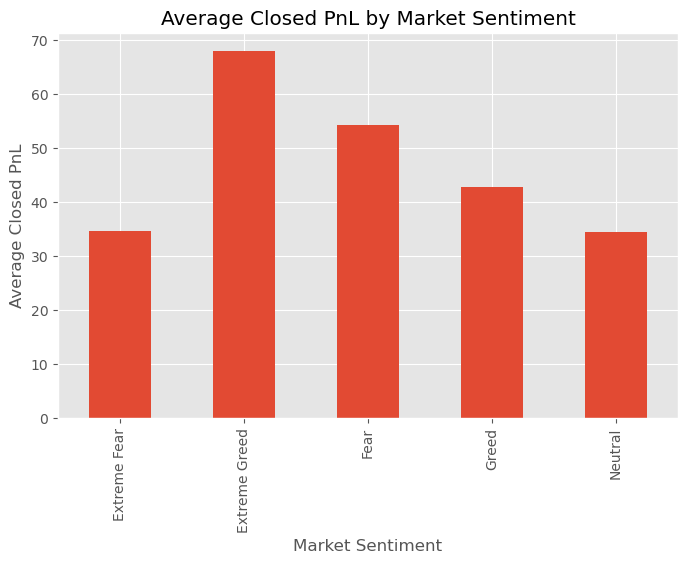

In [65]:
plt.figure(figsize=(8,5))
profit.plot(kind="bar")
plt.title("Average Closed PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.show()

In [66]:
# Trade Count

In [67]:
trade_count = merged["Classification"].value_counts()

print("\nNumber of Trades by Sentiment")
print(trade_count)


Number of Trades by Sentiment
Classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


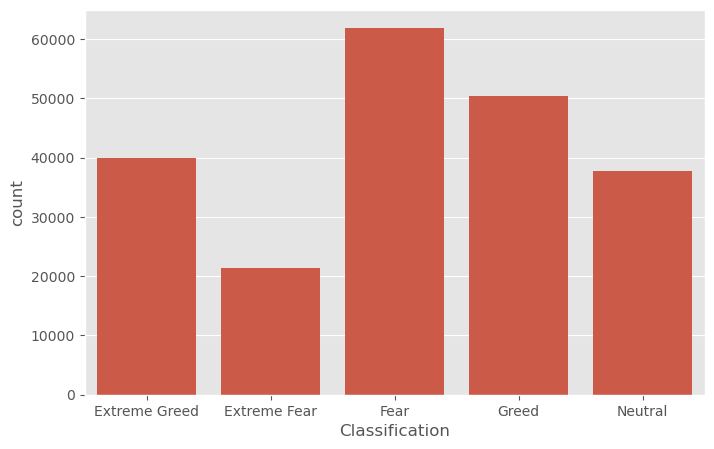

In [68]:
plt.figure(figsize=(8,5))
sns.countplot(data=merged,x="Classification")
plt.show()

# Buy vs Sell Analysis

In [70]:
buy_sell = pd.crosstab(
    merged["Classification"],
    merged["Side"])
print("\nBuy vs Sell Distribution")
print(buy_sell)


Buy vs Sell Distribution
Side              BUY   SELL
Classification              
Extreme Fear    10935  10465
Extreme Greed   17940  22052
Fear            30270  31567
Greed           24576  25727
Neutral         18969  18717


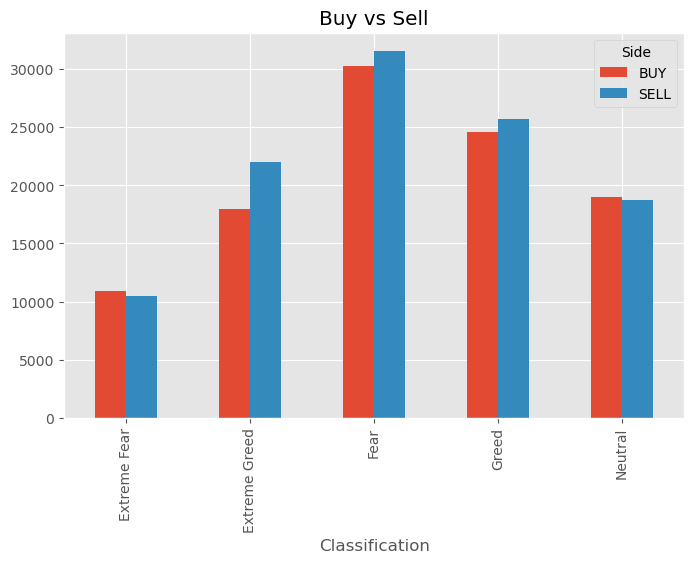

In [71]:
buy_sell.plot(kind="bar",figsize=(8,5))
plt.title("Buy vs Sell")
plt.show()

In [72]:
# Top Coins

In [73]:
coins = merged["Coin"].value_counts().head(10)
print(coins)

Coin
HYPE         68005
@107         29992
BTC          26064
ETH          11158
SOL          10691
FARTCOIN      4650
MELANIA       4428
PURR/USDC     2774
WLD           1983
SUI           1979
Name: count, dtype: int64


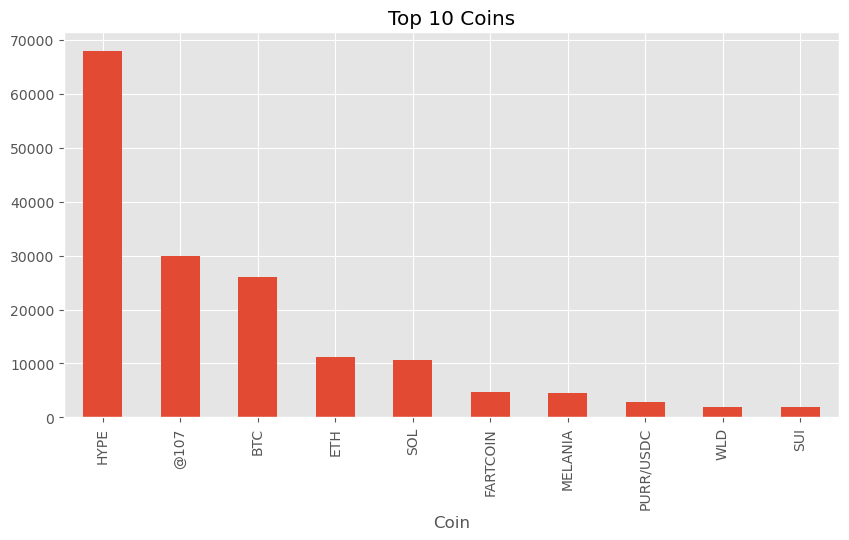

In [74]:
plt.figure(figsize=(10,5))
coins.plot(kind="bar")
plt.title("Top 10 Coins")
plt.show()

In [75]:
# Top Traders

In [80]:
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Profitable Traders")
print(top_traders)


Top 10 Profitable Traders
Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


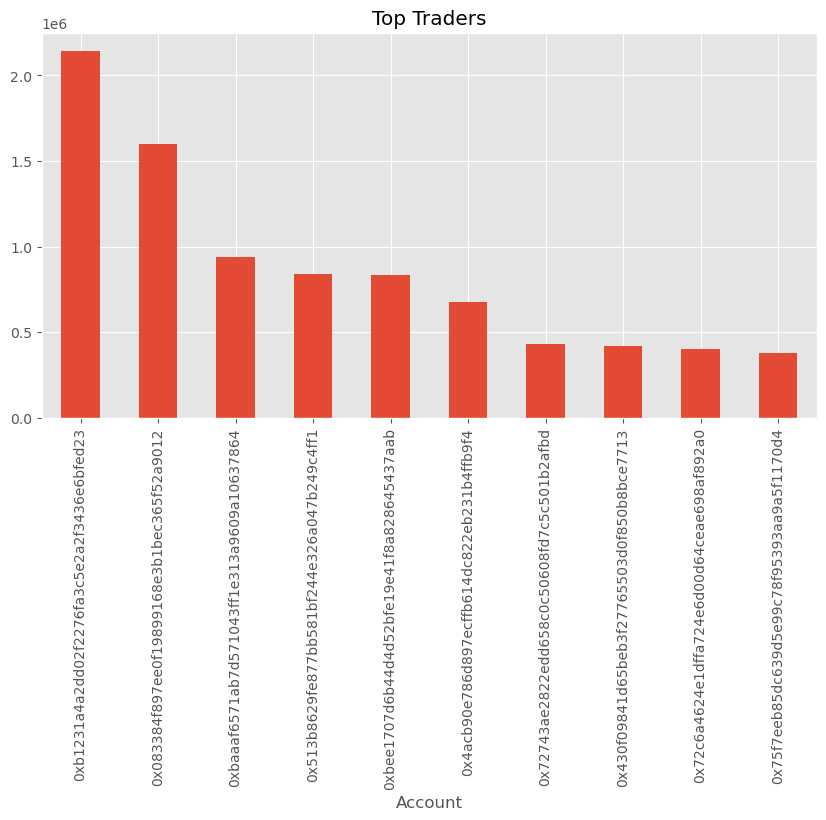

In [81]:
top_traders.plot(kind="bar",figsize=(10,5))
plt.title("Top Traders")
plt.show()


In [84]:
# Trade Size

In [85]:
trade_size = merged.groupby("Classification")["Size USD"].mean()
print(trade_size)

Classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


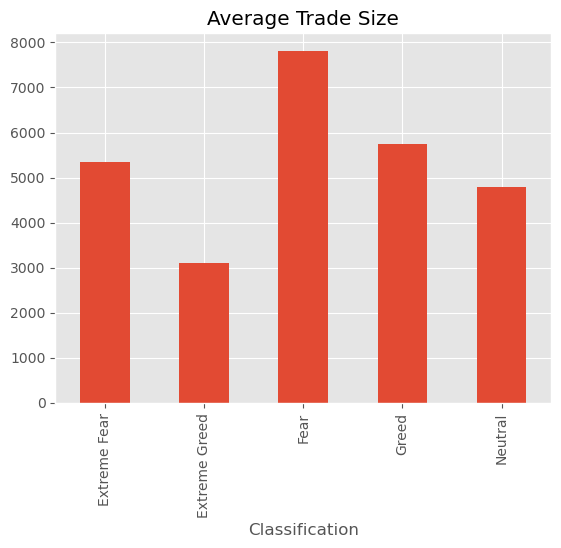

In [86]:
trade_size.plot(kind="bar")
plt.title("Average Trade Size")
plt.show()

In [87]:
# Correlation
numeric = merged.select_dtypes(include=np.number)
corr = numeric.corr()
print("\nCorrelation Matrix")
print(corr)


Correlation Matrix
                 Execution Price  Size Tokens  Size USD  Start Position  \
Execution Price         1.000000    -0.017185  0.189855        0.017241   
Size Tokens            -0.017185     1.000000  0.013310        0.044660   
Size USD                0.189855     0.013310  1.000000        0.007787   
Start Position          0.017241     0.044660  0.007787        1.000000   
Closed PnL             -0.006505     0.005068  0.123589        0.004066   
Order ID                0.125850    -0.043753  0.045210       -0.082799   
Fee                     0.225265     0.006710  0.745939        0.010559   
Trade ID                0.001841    -0.003848  0.000245        0.001165   
Timestamp               0.130714    -0.040949  0.039755       -0.105487   

                 Closed PnL  Order ID       Fee  Trade ID  Timestamp  
Execution Price   -0.006505  0.125850  0.225265  0.001841   0.130714  
Size Tokens        0.005068 -0.043753  0.006710 -0.003848  -0.040949  
Size USD        

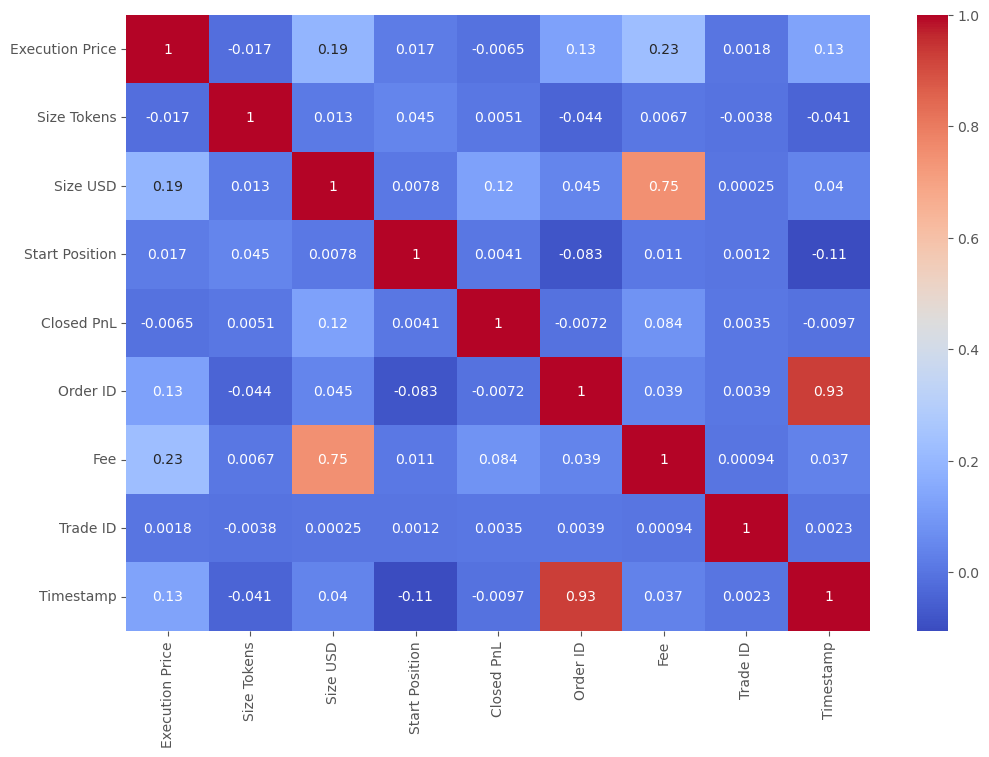

In [88]:
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

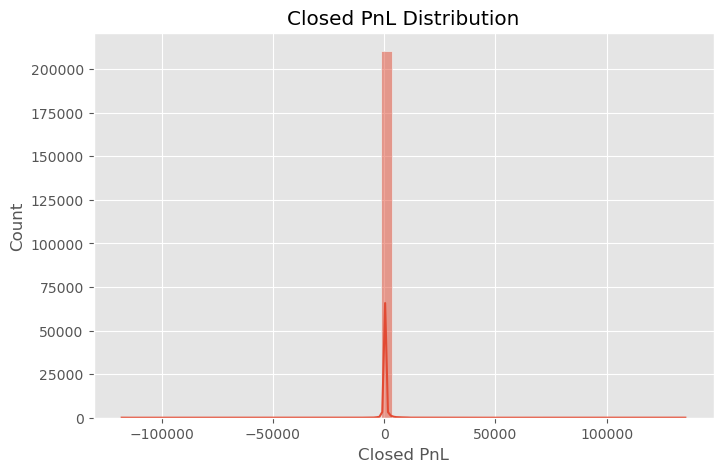

In [89]:
# Histogram
plt.figure(figsize=(8,5))
sns.histplot(merged["Closed PnL"],bins=50,kde=True)
plt.title("Closed PnL Distribution")
plt.show()


In [93]:

print("Total Trades :", len(merged))
print("Unique Traders :", merged["Account"].nunique())
print("Most Traded Coin :", merged["Coin"].mode()[0])
print("Highest Profit :", merged["Closed PnL"].max())
print("Lowest Profit :", merged["Closed PnL"].min())
print("Average Closed PnL :", round(merged["Closed PnL"].mean(),2))
print("\nAverage Profit by Sentiment")
print(profit)
print("\nAnalysis Completed Successfully!")

Total Trades : 211224
Unique Traders : 32
Most Traded Coin : HYPE
Highest Profit : 135329.0901
Lowest Profit : -117990.1041
Average Closed PnL : 48.75

Average Profit by Sentiment
Classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64

Analysis Completed Successfully!
